# Análisis de Componentes Principales (PCA)

Supongamos que tenemos un cuadrado de lado $2r$ con $N$ puntos cayendo dentro de área. Si ahora dibujamos una circunferencia de radio $r$, ¿Cuál es la porción de putnos que caen dentro del radio $r$ centrado en cero?

El panorama es el siguiente: dentro del área rectangular $A_1$ tenemos $N$ puntos y queremos saber la _fracción_ de puntos que caen dentro del área circular $A_2$,
\begin{align}
A_1 & \rightarrow N\\
A_2 & \rightarrow ?
\end{align}
Dada la **distribución uniforme**, tendremos que determinar cuál es la freacción de área que cubre la circunferencia respecto al cuadrado y así sabremos la fracción de puntos: la mitad del área tendrá aproximadamente la mitad de los puntos, un cuarto del área tendrá un cuarto del número de puntos y así sucesivamente. Así
\begin{equation}
f = \frac{A_2}{A_1} = \frac{\pi r^2}{4r^2} = \frac{\pi}{4} \approx 78.5\%
\end{equation}
Vamos a visualizar este ejemplo:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x=np.random.uniform(-5, 5, 100)
y=np.random.uniform(-5,5,100)

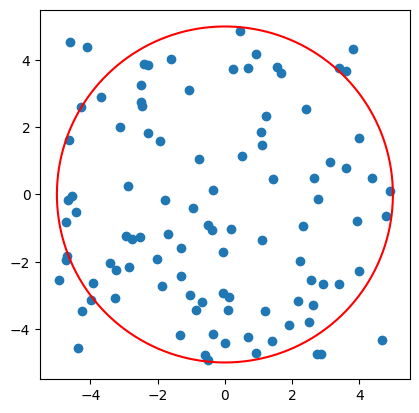

In [3]:
plt.scatter(x, y)

# Circunferencia
theta = np.linspace(0, 2*np.pi, 500)
x_pol = 5*np.cos(theta)
y_pol = 5*np.sin(theta)

plt.plot(x_pol, y_pol, color = 'red')
plt.ylim(-5.5, 5.5)
plt.xlim(-5.5, 5.5)

plt.gca().set_aspect('equal', adjustable='box')
plt.show()

Conforme generamos nuevos puntos aleatoriamente, podrémos verificar que al rededor de 22 puntos quedan fuera de la circunferencia, por lo que el resto, 78 puntos de 100, están encerrados en la circunferencia.

¿Qué pasa si tomamos ahora figuras 3-dimensionales? La lógica sigue siendo la misma,
\begin{equation}
f = \frac{V_2}{V_1} = \frac{4 \pi r^3/3}{8 r^3} = \frac{\pi}{6} \approx 52.3\%
\end{equation}

La conclusión es que a medida que aumentamos las dimensiones, la fracción de puntos encerrados en un radio $r$ irá disminuyendo. Tomando el límite $\lim_{D \rightarrow \inf} f_D$ la fracción tiende a **cero** y el número de datos requeridos para generar una muestra uniforme del volumen aumenta exponencialmente.
\\

En clusters cosmológicos, la probabilidad de encontrar objetos con características específicas tiende a cero, y conforme el número de especificaciones crece, la probabilidad siminuye. En estos casos es conveniente **reducir la dimensionalidad**. Para esto hay varios caminos:
- Eliminar variables: No todas las variables afectan de la misma forma a las observables. Descartamos aquellas que afectan menos.
- Extracción de análisis: Usamos solo las n-primeras variables. Es decir, creamos un nuevo set de variables que más afectan a la observable.
- **PCA**: Encontrar combinaciones de variables que sean independientes, ordenadas por importancia.

Para PCA, para $N$ observables y $k$ variables obtenemos una matriz $N*k$. Por ejemplo: flujo por bin de longitud de onda para N espectros. Podrémos construír cualquier vector de la matriz original a partir de la combinanción lineal de los _eigenvalores_ y los _eigenvectores_ coinciden con las direcciones de máxima variación.

## NOTA: Cambiar kernel a "Phyton (PCA)"

A continuación trabajamos con espectros astronómicos, específicamente con cuasares (también puede adaptarse para galaxias y estrellas). Los análisis de reducción de dimensiones son útiles sobre todo en clusters como SDSS, DESI, etc donde el espacio de parámetros y el número de datos es enorme. 
Analisarémos métodos PCA, ICA y NFM.

Como referencia se tomó el notebook de DESI "DESI_access_spectra.ipynb"

In [4]:
from astropy.convolution import convolve, Gaussian1DKernel

## DataLab and SPARCL related modules
from sparcl.client import SparclClient
from dl import queryClient as qc

/Users/jcimental/venvs/lab-env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [5]:
## Instantiate SPARCLClient
client = SparclClient()

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


In [6]:
# Write a query to select the primary spectrum in the Main survey for .1% of the sample
query = """
        SELECT zp.targetid, zp.z
        FROM desi_dr1.zpix AS zp
        WHERE (zp.survey='main') AND (zp.spectype ='QSO') AND zp.main_primary AND (zp.random_id BETWEEN 0. AND 0.1)
        """ 

In [7]:
zpix_cat = qc.query(sql = query, fmt = 'table')

In [8]:
zpix_cat

targetid,z
int64,float64
39627751036029644,2.240708255153232
39628033765676308,2.361188543850257
39627980468654898,2.516868132018854
39627845382705283,2.578377403839813
39627805423570435,1.195947426767599
39628522691496063,2.038919499292838
39633048932715775,2.071228211281864
39632966330089683,0.9313820300047977
...,...


In [9]:
targetid=zpix_cat['targetid'].data.tolist()

Aprovechamos que tenemos acceso a los datos para visualizar los objetos con los que vamos a trabajar (este paso no es necesario).

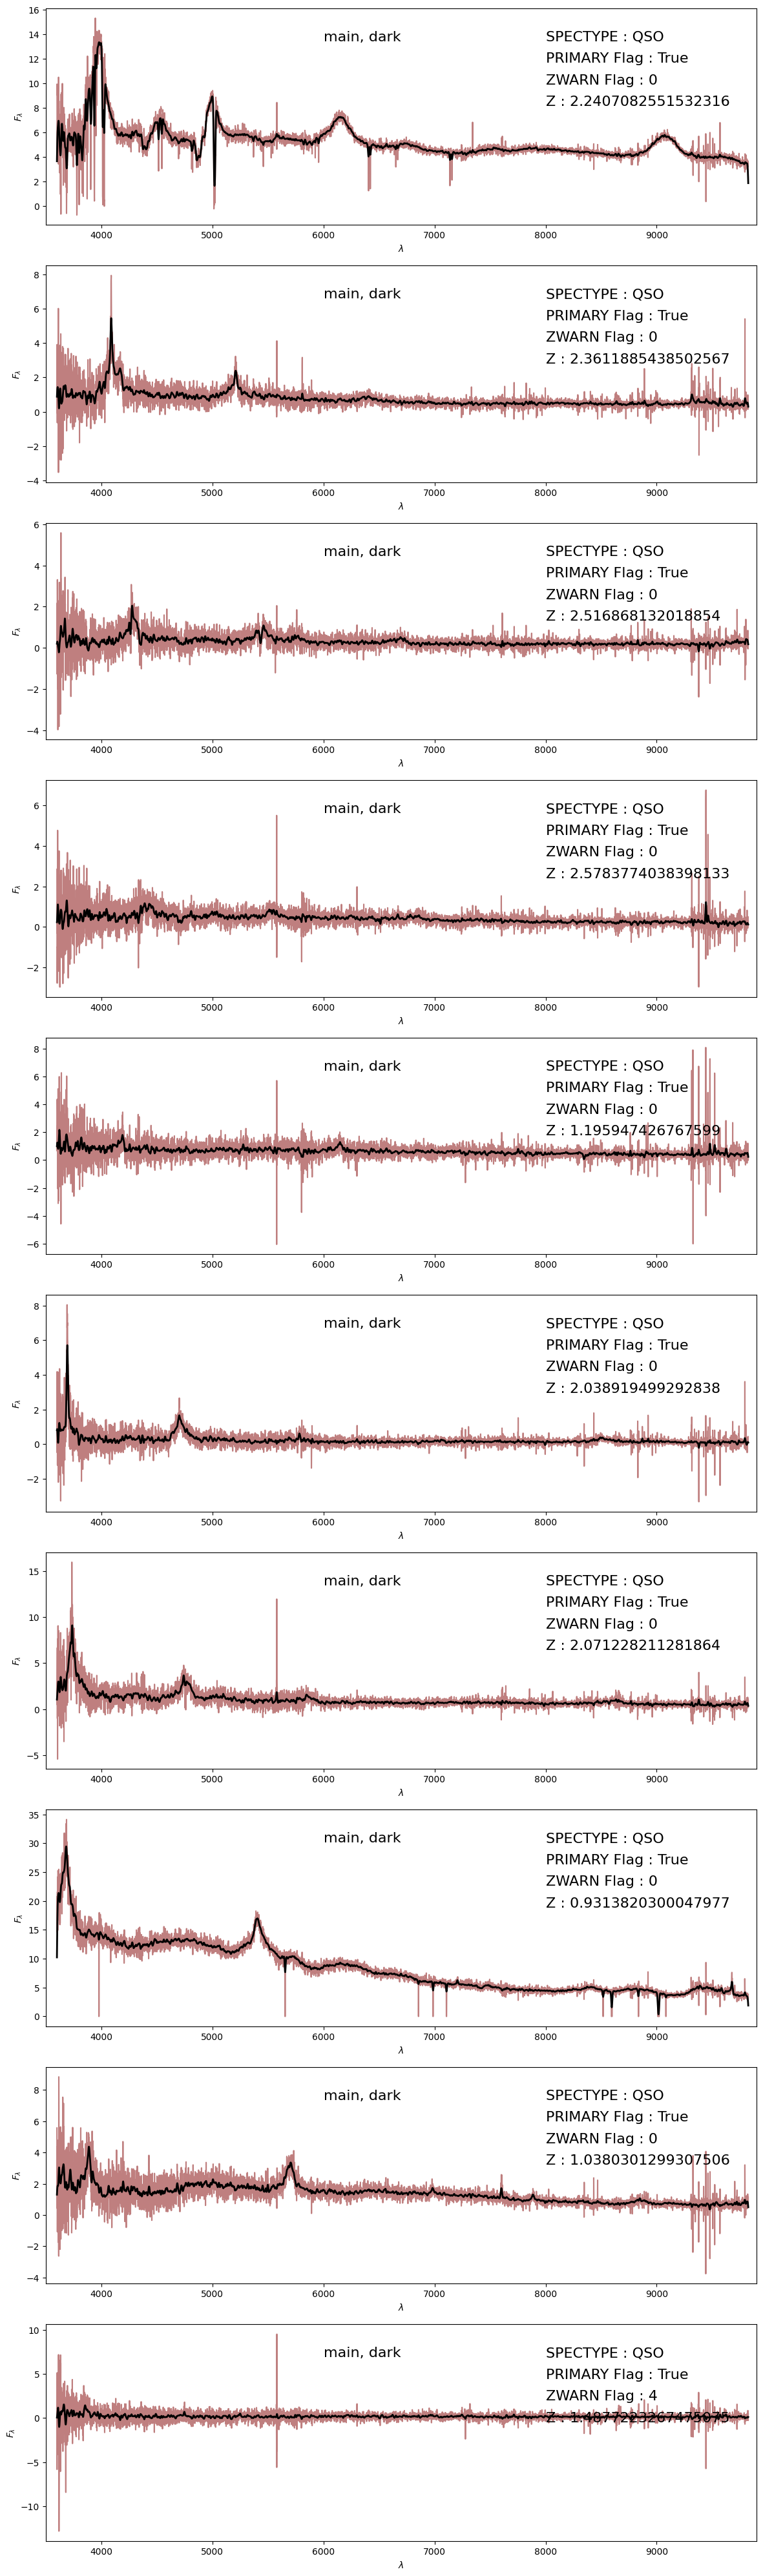

In [10]:
# Number of spectra to plot
n =10 #len(targetid)
#wave_vec = []
flux_vec = []

fig, ax = plt.subplots(n, 1, figsize = (12,(4*n)))

for jj in range(n):
    inc = ['specid', 'redshift', 'flux', 'wavelength', 'spectype', 'specprimary', 'survey', 'program', 'targetid', 'redshift_warning']
    res = client.retrieve_by_specid(specid_list = [targetid[jj]],   ## Client tiene los datos de SDSS, elige objetos de la
                                include = inc,                       # lista de zcat y obtiene los atributos "inc"
                                dataset_list = ['DESI-DR1'])
    records = res.records                     ## records es una lista de listas, auqnue solo tiene un elemento porque el 
    survey = records[0].survey                 # ciclo va uno por uno. Por eso siempre se elige el elemento 0.
    program = records[0].program
    spectype = records[0].spectype
    primary_flag = records[0].specprimary
    zwarn_flag = records[0].redshift_warning
    redshift = records[0].redshift

    lam = records[0].wavelength
    flam = records[0].flux

    flux_vec.append(flam)
    
    # Plot the combined spectrum in maroon
    ax[jj].plot(lam, flam, color = 'maroon', alpha = 0.5)
    # Over-plotting smoothed spectra 
    ax[jj].plot(lam, convolve(flam, Gaussian1DKernel(5)), color = 'k', lw = 2.0)
    ax[jj].set(xlim = [3500, 9900], xlabel = r'$\lambda$', ylabel = r'$F_{\lambda}$')
    trans = ax[jj].get_xaxis_transform()
    ax[jj].annotate(f'{survey}, {program}', xy = (6000, 0.85), xycoords = trans, fontsize = 16)
    ax[jj].annotate(f'SPECTYPE : {spectype}', xy = (8000, 0.85), xycoords = trans, fontsize = 16)
    ax[jj].annotate(f'PRIMARY Flag : {primary_flag}', xy = (8000, 0.75), xycoords = trans, fontsize = 16)
    ax[jj].annotate(f'ZWARN Flag : {zwarn_flag}', xy = (8000, 0.65), xycoords = trans, fontsize = 16)
    ax[jj].annotate(f'Z : {redshift }', xy = (8000, 0.55), xycoords = trans, fontsize = 16)
    
plt.tight_layout()

In [11]:
#res = client.retrieve_by_specid(specid_list = targetid,   ## Client tiene los datos de SDSS, elige objetos de la
#                                include = inc,                       # lista de zcat y obtiene los atributos "inc"
#                               dataset_list = ['DESI-DR1'])

In [12]:
#records = res.records

In [13]:
#lam = records[0].wavelength
#flam = records[0].flux

Generamos una matriz $N \times k$ que utilizarémos en los análisis y cargamos las paqueterías:
- _sklearn_: ya incluye el pipeline para extraer los componentes principales para los tres métodos.
- _astroML_: guarda los datos obtenidos con sklearn en un archivo ".pkl"

Como referencia se tomó el notebook: https://www.astroml.org/book_figures/chapter7/fig_spec_decompositions.html

In [14]:
spectra = np.vstack(flux_vec).astype(np.float32)

spectra.shape

(10, 7781)

In [15]:
from sklearn.decomposition import NMF, FastICA, PCA
from astroML.utils.decorators import pickle_results

In [16]:
if "setup_text_plots" not in globals():
    print('no')
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

no


/Users/jcimental/venvs/lab-env/lib/python3.9/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


In [17]:
@pickle_results('DESI_spec_decom.pkl')    ## Guarda automáticamente resultados en spec_decomposition.pkl'
def compute_PCA_ICA_NMF(n_components):
    spec_mean = spectra.mean(0)

    # PCA: use randomized PCA for speed
    pca = PCA(n_components - 1, random_state=0, svd_solver='randomized')  ## random fija la semilla para tomar 
                                                                           # los mismos espectros
                                                                           # randomized evita diagonalizar la matriz enorme
    pca.fit(spectra)                                                      ## Obtiene los componentes principales
    pca_comp = np.vstack([spec_mean,                                      ## agrega el mean al principio
                          pca.components_])

    # ICA treats sequential observations as related.  Because of this, we need
    # to fit with the transpose of the spectra
    ica = FastICA(n_components - 1, random_state=0)
    ica.fit(spectra.T)                                          ## ICA necesita (gal1(wave1), gal1(wave2), gal1(wave3), ...)
                                                                 #              (gal2(wave1), gal2(wave2), gal2(wave3), ...)
                                                                 #              ( ...            ...           ...         )
                                                                 # es decir (wave, gal) en lugar de (gal, wave)
    ica_comp = np.vstack([spec_mean,
                          ica.transform(spectra.T).T])          ## vuelve al orden (gal, wave)

    # NMF requires all elements of the input to be greater than zero
    spectra[spectra < 0] = 0                                    ## Solo acepta valores positivos del espectro!
    nmf = NMF(n_components, random_state=0)
    nmf.fit(spectra)
    nmf_comp = nmf.components_                                  ## PCA -> data = mean + modos
                                                                 # ICA -> data = mean + independent fluctiations
                                                                 # NMF -> data  = c_i N_i     (no necesita el mean) 
    return pca_comp, ica_comp, nmf_comp

n_components = 5
decompositions = compute_PCA_ICA_NMF(n_components)

@pickle_results: using precomputed results from 'DESI_spec_decom.pkl'


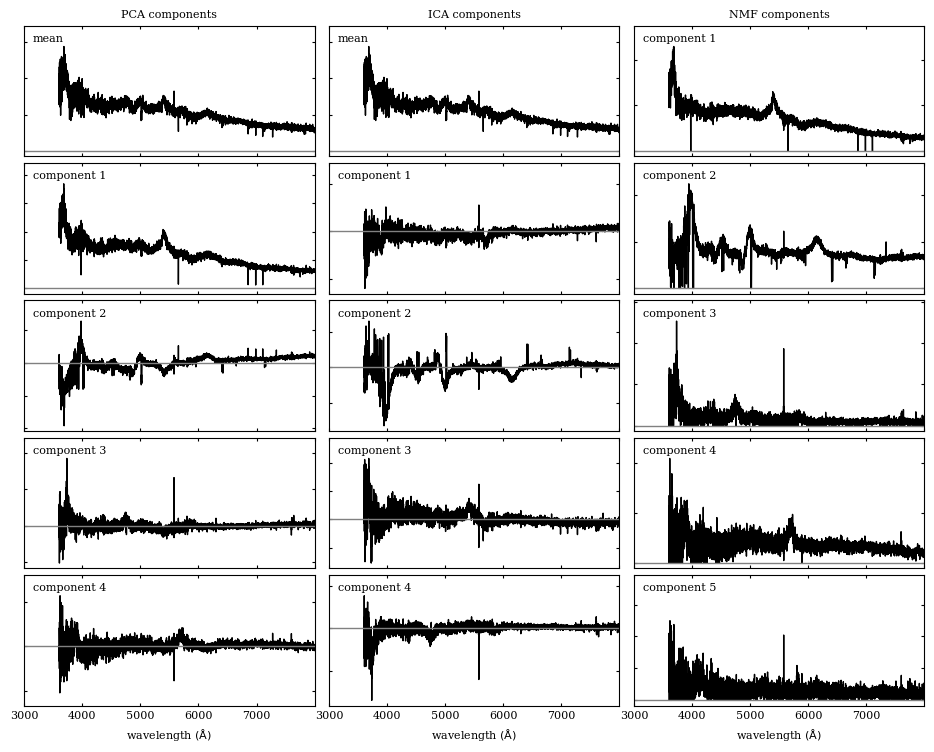

In [18]:
fig = plt.figure(figsize=(10, 8))
fig.subplots_adjust(left=0.05, right=0.95, wspace=0.05,
                    bottom=0.1, top=0.95, hspace=0.05)

titles = ['PCA components', 'ICA components', 'NMF components']

for i, comp in enumerate(decompositions):
    for j in range(n_components):
        ax = fig.add_subplot(n_components, 3, 3 * j + 1 + i)

        ax.yaxis.set_major_formatter(plt.NullFormatter())
        ax.xaxis.set_major_locator(plt.MultipleLocator(1000))
        if j < n_components - 1:
            ax.xaxis.set_major_formatter(plt.NullFormatter())
        else:
            ax.xaxis.set_major_locator(
                plt.FixedLocator(list(range(3000, 7999, 1000))))
            ax.set_xlabel(r'wavelength ${\rm (\AA)}$')

        ax.plot(lam, comp[j], '-k', lw=1)

        # plot zero line
        xlim = [3000, 8000]
        ax.plot(xlim, [0, 0], '-', c='gray', lw=1)

        if j == 0:
            ax.set_title(titles[i])

        if titles[i].startswith('PCA') or titles[i].startswith('ICA'):
            if j == 0:
                label = 'mean'
            else:
                label = 'component %i' % j
        else:
            label = 'component %i' % (j + 1)

        ax.text(0.03, 0.94, label, transform=ax.transAxes,
                ha='left', va='top')

        for l in ax.get_xticklines() + ax.get_yticklines():
            l.set_markersize(2)

        # adjust y limits
        ylim = plt.ylim()
        dy = 0.05 * (ylim[1] - ylim[0])

        ax.set_ylim(ylim[0] - dy, ylim[1] + 4 * dy)
        ax.set_xlim(xlim)


plt.show()

In [19]:
from astroML import datasets

In [20]:
pca = PCA()
pca.fit(spectra)
evals = pca.explained_variance_ratio_
evals_cs = evals.cumsum()

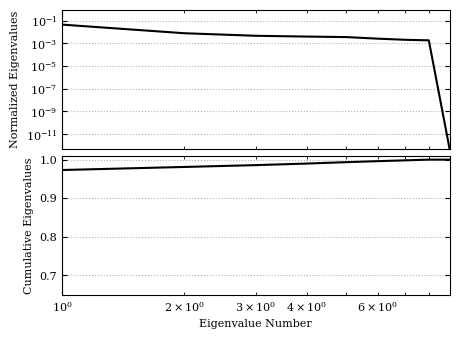

In [22]:
fig = plt.figure(figsize=(5, 3.75))
fig.subplots_adjust(hspace=0.05, bottom=0.12)

ax = fig.add_subplot(211, xscale='log', yscale='log')
ax.grid()
ax.plot(evals, c='k')
ax.set_ylabel('Normalized Eigenvalues')
ax.xaxis.set_major_formatter(plt.NullFormatter())
#ax.set_ylim(5E-4, 100)

ax = fig.add_subplot(212, xscale='log')
ax.grid()
ax.semilogx(evals_cs, color='k')
ax.set_xlabel('Eigenvalue Number')
ax.set_ylabel('Cumulative Eigenvalues')
ax.set_ylim(0.65, 1.01)

plt.show()

IndexError: index 19 is out of bounds for axis 0 with size 10

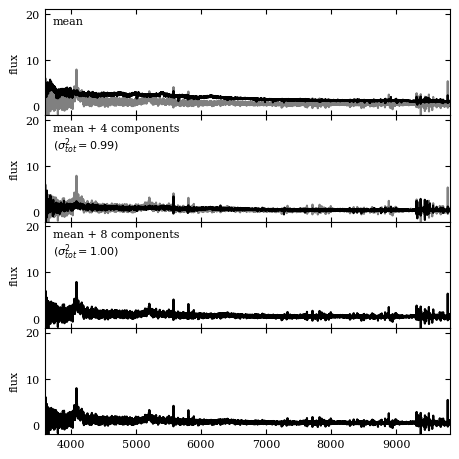

In [24]:
evecs = pca.components_
spec_mean = spectra.mean(0)

#------------------------------------------------------------
# Find the coefficients of a particular spectrum
spec = spectra[1]
coeff = np.dot(evecs, spec - spec_mean)

#------------------------------------------------------------
# Plot the sequence of reconstructions
fig = plt.figure(figsize=(5, 5))
fig.subplots_adjust(hspace=0, top=0.95, bottom=0.1, left=0.12, right=0.93)

for i, n in enumerate([0, 4, 8, 20]):
    ax = fig.add_subplot(411 + i)
    ax.plot(lam, spec, '-', c='gray')
    ax.plot(lam, spec_mean + np.dot(coeff[:n], evecs[:n]), '-k')

    if i < 3:
        ax.xaxis.set_major_formatter(plt.NullFormatter())

    ax.set_ylim(-2, 21)
    ax.set_ylabel('flux')

    if n == 0:
        text = "mean"
    elif n == 1:
        text = "mean + 1 component\n"
        text += r"$(\sigma^2_{tot} = %.2f)$" % evals_cs[n - 1]
    else:
        text = "mean + %i components\n" % n
        text += r"$(\sigma^2_{tot} = %.2f)$" % evals_cs[n - 1]

    ax.text(0.02, 0.93, text, ha='left', va='top', transform=ax.transAxes)

fig.axes[-1].set_xlabel(r'${\rm wavelength\ (\AA)}$')
plt.show()

### DUDAS:
- Para los ejercicios, cuántos espectros hay que tomar aproximadamente? Para que corra adecuadamente el último ejercicio
- Intenté tomar todo el conjunto targetid pero al parecer los "records" solo se pueden obtener de 500, los otros 1221 no.
- El tutorial usa "evecs = data['evecs']" y "evals = data['evals'] ** 2". Los datos de SDSS ya tienen auto valores y vectores...